# Lab 5.1 — Adversarial Examples and Model Robustness

*Chapter 5 — AI Security, Risks, and Responsible AI · 40 minutes (flex —
your instructor may skip this) · JupyterLab with pandas, scikit-learn and
matplotlib — no API key needed*

You are testing a classifier before it goes anywhere near a decision. Your
job is to break it on purpose, in a sandbox, and report honestly.

Cells marked `# YOUR CODE` are for you to complete. No API key is needed.

## Objectives

By the end of this lab, you will:

- Craft inputs that flip a model's prediction.
- Measure how much perturbation it actually takes.
- Name the defences that would have helped.

## Setup

**Datasets and files** (all under `labs/data/`):

- `epa_aqi_by_county.csv` — EPA Annual Air Quality Index by county, 2024
  (real, public; see `data/MANIFEST.json`)

**Tools:** pandas, scikit-learn (logistic regression), matplotlib. This lab
is fully self-contained — no OpenAI key is required.

**Data rule:** the dataset is genuinely public US government data. The
attack you build runs against a throwaway model in this sandbox — never
point these techniques at a system you do not own.

## Steps

1. Open `lab_5.1_adversarial.ipynb` and train the small classifier
   provided. (6 min)
2. Record its baseline accuracy on the held-out set. (5 min)
3. Perturb one feature at a time and find the smallest change that flips a
   prediction. (8 min)
4. Plot flip rate against perturbation size. (8 min)
5. Apply one defence from the chapter and re-measure. (8 min)
6. Write what you would tell a system owner in three sentences. (5 min)

### Step 1 — Train the small classifier (6 min)

The model: predict whether a county had **any** Unhealthy-or-worse air days
in 2024 (`poor_air`), from its day-count profile. A logistic regression —
small, inspectable, and easy to attack honestly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

epa = pd.read_csv("data/epa_aqi_by_county.csv")
epa["poor_air"] = ((epa["Unhealthy Days"] + epa["Very Unhealthy Days"]
                    + epa["Hazardous Days"]) > 0).astype(int)

FEATURES = ["Good Days", "Moderate Days",
            "Unhealthy for Sensitive Groups Days", "Days with AQI"]
X = epa[FEATURES].values
y = epa["poor_air"].values
print(f"{len(epa)} counties | positive (poor air): {y.sum()} ({y.mean():.0%})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
clf = LogisticRegression(max_iter=1000).fit(scaler.transform(X_train), y_train)

997 counties | positive (poor air): 159 (16%)


### Step 2 — Baseline accuracy (5 min)

Record the model's accuracy on the held-out set *before* anyone attacks it.
Also read the coefficients: which feature does the model trust most?

In [2]:
baseline = None
# YOUR CODE: clf's accuracy on the scaled test set.

if baseline is None:
    baseline = clf.score(scaler.transform(X_test), y_test)
    print("(reference answer applied)\n")
print(f"baseline accuracy: {baseline:.1%}")
print("coefficients:", dict(zip(FEATURES, clf.coef_[0].round(2))))

(reference answer applied)

baseline accuracy: 86.8%
coefficients: {'Good Days': np.float64(-0.73), 'Moderate Days': np.float64(-0.5), 'Unhealthy for Sensitive Groups Days': np.float64(1.8), 'Days with AQI': np.float64(1.18)}


### Step 3 — The smallest change that flips one prediction (8 min)

Take one correctly-classified county and perturb **one feature at a time**
— how many extra `Unhealthy for Sensitive Groups Days` does it take before
the model changes its mind? (This is FGSM's question, asked of a model
simple enough that you can watch it happen.)

In [3]:
def predict_raw(row):
    return clf.predict(scaler.transform([row]))[0]

correct = np.where(clf.predict(scaler.transform(X_test)) == y_test)[0]
sample = X_test[correct[5]].copy()
print("sample county:", dict(zip(FEATURES, sample)), "| true label:", y_test[correct[5]])

smallest_flip = None
# YOUR CODE: find the smallest integer you can add to ONE feature of `sample`
# so that predict_raw() disagrees with the true label. Store
# (feature_name, epsilon) in smallest_flip.

if smallest_flip is None:
    for j, f in enumerate(FEATURES):
        for eps in range(1, 400):
            x = sample.copy()
            x[j] += eps
            if predict_raw(x) != y_test[correct[5]]:
                smallest_flip = (f, eps)
                break
        if smallest_flip:
            break
    print("(reference search applied)\n")
print(f"smallest flip found: {smallest_flip[0]} +{smallest_flip[1]} days")

sample county: {'Good Days': np.int64(106), 'Moderate Days': np.int64(16), 'Unhealthy for Sensitive Groups Days': np.int64(0), 'Days with AQI': np.int64(122)} | true label: 0
(reference search applied)

smallest flip found: Unhealthy for Sensitive Groups Days +19 days


### Step 4 — Flip rate vs. perturbation size (8 min)

One flip is an anecdote; a rate is a measurement. For every test county,
push its most sensitive feature by ε (up for clean counties, down for
poor-air ones — the direction that aims at the wrong answer) and count how
many flip.

(reference rates applied)

eps=  1 days -> flip rate 1%
eps=  2 days -> flip rate 2%
eps=  5 days -> flip rate 5%
eps= 10 days -> flip rate 26%
eps= 20 days -> flip rate 84%
eps= 40 days -> flip rate 85%


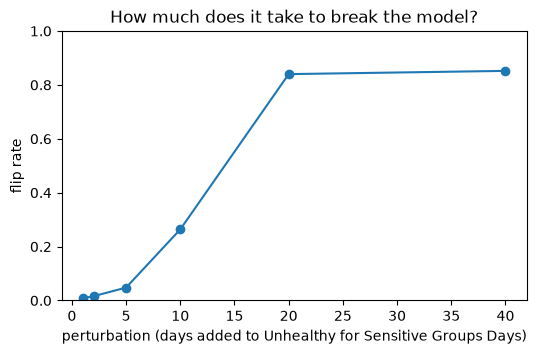

In [4]:
SENSITIVE = "Unhealthy for Sensitive Groups Days"  # largest coefficient
j = FEATURES.index(SENSITIVE)

def flip_rate(model, sc, eps):
    """Fraction of originally-correct test predictions flipped by a
    perturbation of size eps on the sensitive feature."""
    Xp = X_test.copy().astype(float)
    Xp[:, j] = np.clip(Xp[:, j] + np.where(y_test == 1, -eps, eps), 0, None)
    flipped = (model.predict(sc.transform(Xp)) != y_test)
    was_correct = model.predict(sc.transform(X_test)) == y_test
    return float((flipped & was_correct).mean())

EPSILONS = [1, 2, 5, 10, 20, 40]
rates = []
# YOUR CODE: flip_rate(clf, scaler, eps) for each eps in EPSILONS.

if not rates:
    rates = [flip_rate(clf, scaler, e) for e in EPSILONS]
    print("(reference rates applied)\n")
for e, r in zip(EPSILONS, rates):
    print(f"eps={e:>3} days -> flip rate {r:.0%}")

plt.figure(figsize=(6, 3.5))
plt.plot(EPSILONS, rates, marker="o")
plt.xlabel(f"perturbation (days added to {SENSITIVE})")
plt.ylabel("flip rate")
plt.title("How much does it take to break the model?")
plt.ylim(0, 1)
plt.show()

### Step 5 — Apply one defence and re-measure (8 min)

Defence: **adversarial retraining**. Augment the training set with perturbed
copies that keep their *true* labels, retrain, and re-run the same attack.
The model learns that "a few extra USG days" is not, by itself, the signal.

In [5]:
defended_rates = None
# YOUR CODE: build an augmented training set (perturbed copies of X_train at
# eps 5/10/20/40 with the TRUE labels kept), refit scaler + LogisticRegression,
# and store the re-measured flip rates in defended_rates.

if defended_rates is None:
    rng = np.random.default_rng(0)
    aug_X, aug_y = [X_train], [y_train]
    for eps in (5, 10, 20, 40):
        Xa = X_train.copy().astype(float)
        Xa[:, j] = np.clip(Xa[:, j] + np.where(y_train == 1, -eps, eps)
                           * rng.uniform(0.5, 1.0, len(y_train)), 0, None)
        aug_X.append(Xa)
        aug_y.append(y_train)
    X_aug, y_aug = np.vstack(aug_X), np.concatenate(aug_y)
    scaler2 = StandardScaler().fit(X_aug)
    clf2 = LogisticRegression(max_iter=1000).fit(scaler2.transform(X_aug), y_aug)
    defended_rates = [flip_rate(clf2, scaler2, e) for e in EPSILONS]
    print("(reference defence applied — replace with your own)\n")

print("eps   before -> after defence")
for e, b, a in zip(EPSILONS, rates, defended_rates):
    print(f"{e:>3}   {b:5.0%}  ->  {a:.0%}")

(reference defence applied — replace with your own)

eps   before -> after defence
  1      1%  ->  0%
  2      2%  ->  0%
  5      5%  ->  0%
 10     26%  ->  0%
 20     84%  ->  0%
 40     85%  ->  0%


### Step 6 — Three sentences to the system owner (5 min, write here)

*How breakable the model is, what it costs to break it, and what you did
about it:*

-
-
-

## Deliverable
1. Baseline accuracy and the smallest successful perturbation.
2. The flip-rate curve.
3. Before/after flip rates under your defence.
4. Your three sentences to the system owner.

## Reflection
1. How small was the smallest successful perturbation?
2. Would the defence have survived an attacker who *knew about it*?
3. Which MITRE ATLAS tactic does this exercise correspond to?

## Debrief (instructor-led)

- **Compare smallest flips.** How many days did it take around the room?
  What does a "small" perturbation mean when the unit is days of bad air?
- **Defence economics.** Adversarial retraining cost you nothing but
  compute — why isn't it done by default? What attack would defeat it?
- **ATLAS mapping.** Which MITRE ATLAS tactic did you just execute, and
  where in your agency's ML lifecycle would you run this exercise?

## Troubleshooting

- **`FileNotFoundError: data/epa_aqi_by_county.csv`** — the kernel's working
  directory is not `labs/`. Restart the kernel from the `labs/` folder and
  Run All.
- **`ConvergenceWarning` from LogisticRegression** — harmless here; the
  features are scaled and `max_iter=1000` is enough for this tiny model.
- **The plot is empty or missing** — run cells in order (Run All); the
  figure is drawn from `rates`, which the reference path fills if your
  YOUR-CODE list is empty.
- **`smallest_flip` never found** — the reference search caps ε at 400; on
  this data a flip occurs well below that. If your own loop finds nothing,
  check you are perturbing the *scaled* model's raw feature, not the scaled
  value.
- **Numbers differ from a neighbour's** — they should not: the split is
  seeded (`random_state=42`). A difference means a cell was edited or run
  out of order.